# Multimodal Clustering Experiment with Gemini Embeddings
In this notebook, I try to explore the similarities **between different data entries** by generating a single combined embedding for each entry (using both its image and caption simultaneously) via the Gemini API. We analyze the first 10 entries of the `tokyo_first100_local_ok.csv` dataset. Note: Please add your API key below manually.

In [6]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from PIL import Image

# Gemini SDK (NEW)
from google import genai

# Similarity
from sklearn.metrics.pairwise import cosine_similarity

In [7]:
# Load dataset (first 10 rows for testing)
dataset_path = r"c:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Other\Dataset\tokyo_first100_local_ok.csv"

df = pd.read_csv(dataset_path).head(10)

display(df[['photo/video_page_url', 'caption']])

,photo/video_page_url,caption
0,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,Today felt peaceful and steady.
1,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,Feeling happy and light today.
2,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,Feeling sad and missing home.
3,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,"A quiet day, kind of neutral."
4,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,"A quiet day, kind of neutral."
5,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,I’m proud of myself for showing up.
6,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,Today felt peaceful and steady.
7,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,Feeling nostalgic and a bit emotional.
8,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,A calm moment that made me smile.
9,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,Confident—like I can handle things.


In [ ]:
# Configure Gemini API
API_KEY = '' # add your API key here 
client = genai.Client(api_key=API_KEY)

print("Gemini client initialized successfully")

Gemini client initialized successfully


In [9]:
def get_combined_multimodal_embedding(image_path, text):
    """
    Generates a SINGLE embedding using:
    image + caption together (multimodal)

    Returns a vector embedding.
    """

    try:
        img = Image.open(image_path)

        result = client.models.embed_content(
            model="models/gemini-embedding-2-preview",
            contents=[img, text]
        )

        embedding = result.embeddings[0].values
        return np.array(embedding)

    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

In [10]:
combined_embeddings = []

print("Generating multimodal embeddings...")

for idx, row in df.iterrows():

    img_path = row['photo/video_page_url']
    caption = row['caption']

    embedding = get_combined_multimodal_embedding(img_path, caption)

    if embedding is not None:
        combined_embeddings.append(embedding)
    else:
        print(f"Skipping entry {idx}")

combined_embeddings = np.array(combined_embeddings)

print("Total embeddings generated:", len(combined_embeddings))

Generating multimodal embeddings...
Total embeddings generated: 10


In [11]:
# Compute cosine similarity between entries

similarity_matrix = cosine_similarity(
    combined_embeddings,
    combined_embeddings
)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (10, 10)


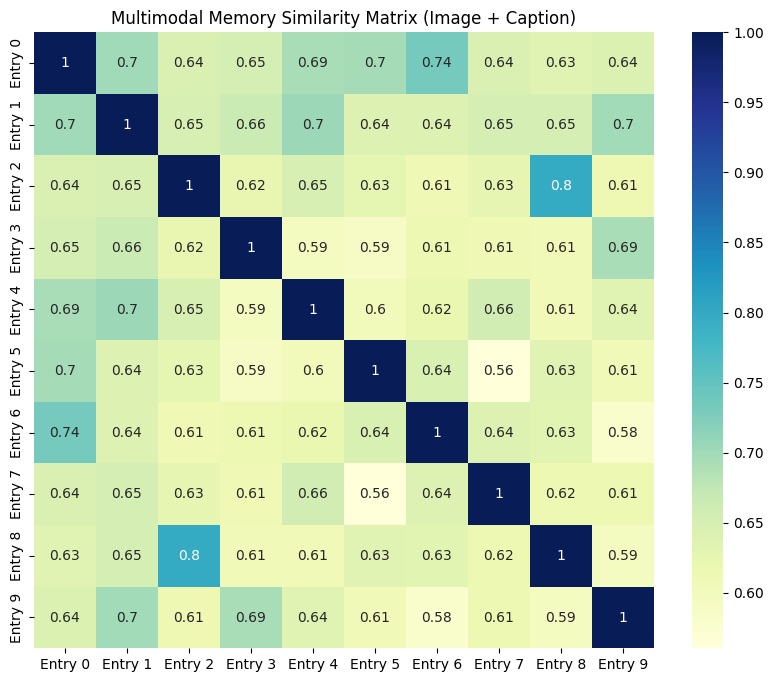

In [12]:
plt.figure(figsize=(10,8))

sns.heatmap(
    similarity_matrix,
    annot=True,
    cmap="YlGnBu",
    xticklabels=[f"Entry {i}" for i in range(len(combined_embeddings))],
    yticklabels=[f"Entry {i}" for i in range(len(combined_embeddings))]
)

plt.title("Multimodal Memory Similarity Matrix (Image + Caption)")
plt.show()

In [13]:
# Show most similar memory pairs

pairs = []

n = len(similarity_matrix)

for i in range(n):
    for j in range(i+1, n):
        pairs.append((i, j, similarity_matrix[i][j]))

pairs.sort(key=lambda x: x[2], reverse=True)

print("Top 5 most similar memories:\n")

for p in pairs[:5]:
    print(f"Entry {p[0]} ↔ Entry {p[1]}  | Similarity = {p[2]:.3f}")

Top 5 most similar memories:

Entry 2 ↔ Entry 8  | Similarity = 0.798
Entry 0 ↔ Entry 6  | Similarity = 0.735
Entry 1 ↔ Entry 4  | Similarity = 0.703
Entry 0 ↔ Entry 1  | Similarity = 0.700
Entry 1 ↔ Entry 9  | Similarity = 0.698


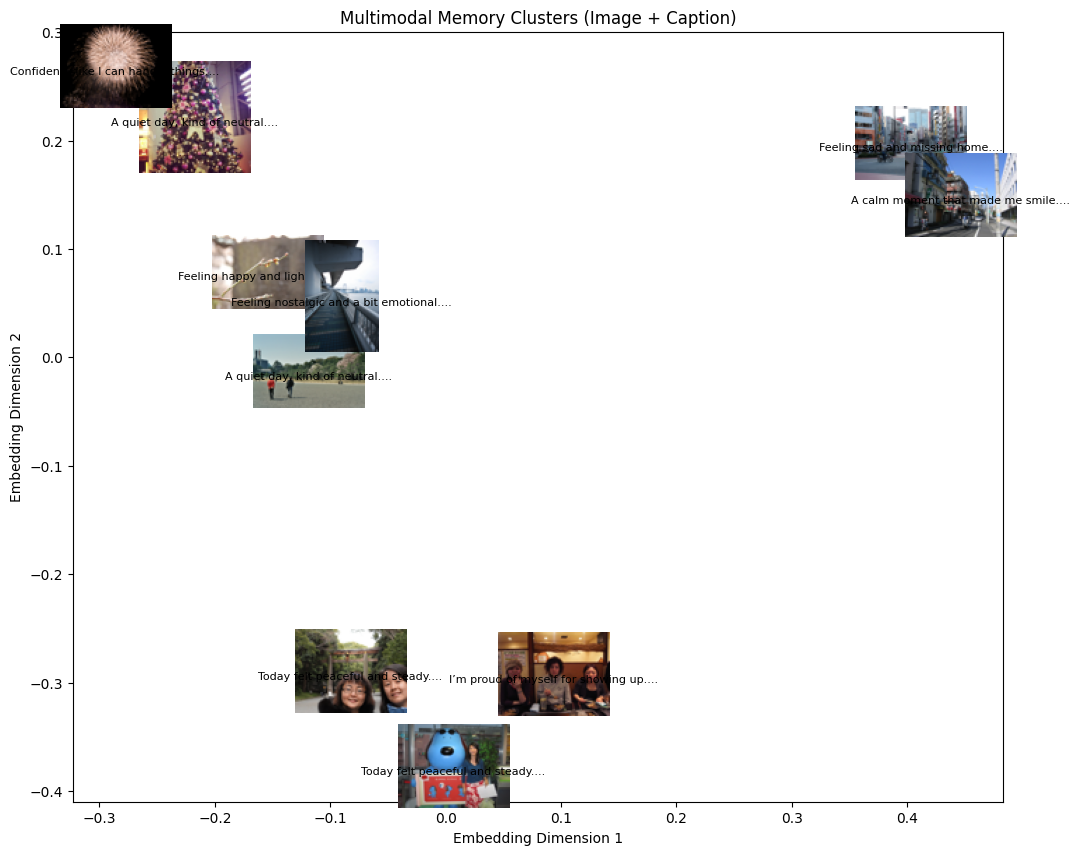

In [16]:
# --- Visualize clusters of memories (image + caption) ---

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Reduce embedding dimension to 2D for visualization
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(combined_embeddings)

# Choose number of clusters
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
clusters = kmeans.fit_predict(combined_embeddings)

# Plot
plt.figure(figsize=(12,10))
ax = plt.gca()

scatter = ax.scatter(
    embeddings_2d[:,0],
    embeddings_2d[:,1],
    c=clusters,
    cmap="tab10",
    s=200
)

# Add image thumbnails
for i, row in df.iloc[:len(embeddings_2d)].iterrows():

    try:
        img = Image.open(row['photo/video_page_url'])
        img.thumbnail((80,80))

        imagebox = OffsetImage(img, zoom=1)
        ab = AnnotationBbox(
            imagebox,
            (embeddings_2d[i][0], embeddings_2d[i][1]),
            frameon=False
        )

        ax.add_artist(ab)

        # add short caption
        caption = str(row['caption'])[:40] + "..."
        ax.text(
            embeddings_2d[i][0],
            embeddings_2d[i][1],
            caption,
            fontsize=8,
            ha='center',
            va='top'
        )

    except:
        continue


plt.title("Multimodal Memory Clusters (Image + Caption)")
plt.xlabel("Embedding Dimension 1")
plt.ylabel("Embedding Dimension 2")
plt.show()